### XGBOOST CLASSIFIER MODELING

The following **XGBoost Classifier models** are prepared:

_Model XG1_     
A simple model is first built.

_Model XG2_   
The class imbalance is addressed using the parameter _scale\_pos\_weight_. The model hyperparameters are also optimized.

_Model XG3_    
Feature selection is applied using SelectKBest.

_Model XG4_    
Feature selection is applied using Random Forest Classifier.        

        

The following **metrics** are determined:    
_AUC_    
_Accuracy_    
_Precision_       
_Recall_    
_F2 Score_       
_Profit/Loss_    

The best model is chosen based on business goals that consider the relative cost of missing a churner (_false negatives_ - predicted not to churn but churned, loss of lifetime value), cost of false alarms (_false positives_ - predicted to churn but stayed, cost of retention offer) and _true positives_ (predicted to stay and actually stayed, saved lifetime value less the cost of retention offer).

In customer churn, missing churners (_recall_) is more expensive than false alarms (_precision_).  Recall is, therefore, optimized at the expense of precision and accuracy.

**Hyperparameters Tuning**    
Model hyperparameters are optimized using grid search to maximize model performance particularly addressing overfitting.  

**Feature Importance**     
The features and their importances are examined to verify the magnitude of features influence on customer churn.   

**Feature Selection**    
Feature selection reduces the number of features to improve the model and to lessen noise. When there is less noise, the interpretability of feature importance improves. Noise in this context is irrelevant information that obscures underlying patterns or relationships the model is trying to learn.  

**Sample Predictions**     
Sample predictions are demonstrated on unseen data.

**Import the required libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier

In [2]:
# Load the cleaned dataset
df = pd.read_csv('cleaned_data.csv')

In [3]:
# Verify info prior to modeling
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7937 entries, 0 to 7936
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  7937 non-null   object 
 1   age                     7937 non-null   int64  
 2   country                 7937 non-null   object 
 3   city                    7937 non-null   object 
 4   customer_segment        7937 non-null   object 
 5   tenure_months           7937 non-null   int64  
 6   signup_channel          7937 non-null   object 
 7   contract_type           7937 non-null   object 
 8   monthly_logins          7937 non-null   int64  
 9   weekly_active_days      7937 non-null   int64  
 10  avg_session_time        7937 non-null   float64
 11  features_used           7937 non-null   int64  
 12  usage_growth_rate       7937 non-null   float64
 13  last_login_days_ago     7937 non-null   int64  
 14  monthly_fee             7937 non-null   

In [4]:
# Define X and y
X = df.drop(['churn'], axis=1)
y = df['churn']

In [5]:
# Split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [6]:
# Define numeric features
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns

['age',
 'tenure_months',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'features_used',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'payment_failures',
 'support_tickets',
 'avg_resolution_time',
 'csat_score',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score',
 'referral_count',
 'churn',
 'tenure_fee_interaction']

In [7]:
# Define numeric_cols less the target variable 'churn'
numeric_cols = ['age','tenure_months','monthly_logins','weekly_active_days','avg_session_time','features_used',
                'usage_growth_rate','last_login_days_ago','monthly_fee','payment_failures','support_tickets',
                'avg_resolution_time','csat_score','escalations','email_open_rate','marketing_click_rate',
                'nps_score','referral_count','tenure_fee_interaction']

print(f'There are {len(numeric_cols)} numeric columns.')

There are 19 numeric columns.


In [8]:
# Verify categorical features for encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response']

In [9]:
# Define the ordinal and nominal features
ordinal_cols = ['contract_type','survey_response']
nominal_cols = ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'payment_method',
                'discount_applied', 'price_increase_last_3m', 'complaint_type']

print(f'There are {len(ordinal_cols)} ordinal columns and {len(nominal_cols)} nominal columns.')

There are 2 ordinal columns and 9 nominal columns.


In [10]:
# Verify 'contract_type' and 'survey_response'

print(df['contract_type'].value_counts(), '\n')
print(df['survey_response'].value_counts())

contract_type
Monthly      3941
Quarterly    2421
Yearly       1575
Name: count, dtype: int64 

survey_response
Satisfied      3940
Neutral        2385
Unsatisfied    1612
Name: count, dtype: int64


In [11]:
# Define ordinal categories
ordinal_categories=[
  ['Monthly','Quarterly','Yearly'],         # contract_type
  ['Unsatisfied','Neutral','Satisfied']     # survey_response
]

**Model XG1**    
A simple model is built.

In [12]:
# Update the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ("nom", OneHotEncoder(drop='if_binary', handle_unknown="ignore"), nominal_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [13]:
# Build pipeline for a simple model
xgb_pipe_simple = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(random_state=42))
])
xgb_pipe_simple.fit(X_train, y_train)
xgb_pipe_simple

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [14]:
# Accuracy of model on train and test data
xgb_pipe_simple_acc_train = xgb_pipe_simple.score(X_train, y_train)
xgb_pipe_simple_acc_test = xgb_pipe_simple.score(X_test, y_test)

print(f'The train accuracy of the model is {xgb_pipe_simple_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {xgb_pipe_simple_acc_test*100:.2f}%')

The train accuracy of the model is 99.98%
The test accuracy of the model is 89.11%


The model is overfitting and is improved by addressing the class imbalance, using hyperparameter tuning and the evaluation metric 'f1'. The next model is called **Model XG2**.

In [15]:
# Address the class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg/pos

In [16]:
# Build pipeline for the improved model
pipe_XG2 = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42))
])
pipe_XG2.fit(X_train, y_train)
pipe_XG2

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [17]:
# Define the hyperparameter grid to be fed to HalvingRandomSearchCV
param_grid_XG2 = {
    'xgb__n_estimators': [200, 300, 500],
    'xgb__max_depth': [4, 6, 8],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0],
    'xgb__gamma': [0, 0.1, 0.3],
    'xgb__min_child_weight': [1, 3, 5]
}

In [18]:
# Run HalvingRandomSearchCV to find the optimum mix of parameters
grid_search_XG2 = HalvingRandomSearchCV(pipe_XG2, param_grid_XG2, cv=3, scoring='f1', n_jobs=-1)
grid_search_XG2.fit(X_train, y_train)

print(f'Best parameters: {grid_search_XG2.best_params_}')
print(f'Best score: {grid_search_XG2.best_score_:.4f}')

Best parameters: {'xgb__subsample': 0.8, 'xgb__n_estimators': 200, 'xgb__min_child_weight': 5, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0.3, 'xgb__colsample_bytree': 0.8}
Best score: 0.3784


In [19]:
# Access the optimized xgb_pipe1 pipeline model
grid_search_XG2_opt = grid_search_XG2.best_estimator_
grid_search_XG2_opt

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method'...
                               feature_types=None, feature_weights=None,
                               gamma=0.3, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None, min_child_weight=5,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=200,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [20]:
# Accuracy of model on train and test data
grid_search_XG2_opt_acc_train = grid_search_XG2_opt.score(X_train, y_train)
grid_search_XG2_opt_acc_test = grid_search_XG2_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_search_XG2_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_search_XG2_opt_acc_test*100:.2f}%')

The train accuracy of the model is 75.43%
The test accuracy of the model is 75.13%


In [21]:
# Generate classification report XG2
y_pred_XG2 = grid_search_XG2_opt.predict(X_test)

print(classification_report(y_test, y_pred_XG2))

              precision    recall  f1-score   support

           0       0.99      0.73      0.84      1439
           1       0.26      0.92      0.41       149

    accuracy                           0.75      1588
   macro avg       0.63      0.83      0.63      1588
weighted avg       0.92      0.75      0.80      1588



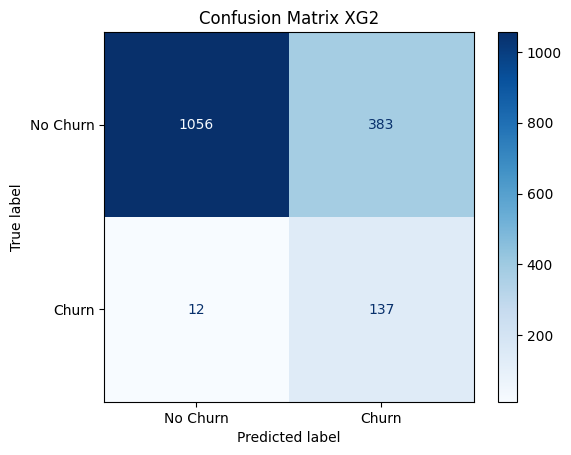

In [22]:
# Display confusion matrix XG2
conf_matrix_XG2 = confusion_matrix(y_test, y_pred_XG2)
disp_XG2 = ConfusionMatrixDisplay(conf_matrix_XG2, display_labels=['No Churn','Churn'])
disp_XG2.plot(cmap='Blues')
plt.title('Confusion Matrix XG2')
plt.show()

In [23]:
# Values for false positive (fp_XG2), false negative (fn_XG2), true positive (tp_XG2) and true negative (tn_XG2)
fp_XG2 = conf_matrix_XG2[0][1]
fn_XG2 = conf_matrix_XG2[1][0]
tp_XG2 = conf_matrix_XG2[1][1]
tn_XG2 = conf_matrix_XG2[0][0]

print(f' fp_XG2: {fp_XG2} \n fn_XG2: {fn_XG2} \n tp_XG2: {tp_XG2} \n tn_XG2: {tn_XG2}')

 fp_XG2: 383 
 fn_XG2: 12 
 tp_XG2: 137 
 tn_XG2: 1056


In [24]:
# Calculations for accuracy, precision, recall
accuracy_XG2 = (tp_XG2 + tn_XG2)/len(y_test)
precision_XG2 = tp_XG2/(tp_XG2 + fp_XG2)
recall_XG2 = tp_XG2/(tp_XG2 + fn_XG2)

print(f'Accuracy: {accuracy_XG2:.2f}')
print(f'Precision: {precision_XG2:.2f}')
print(f'Recall: {recall_XG2:.2f}')
print(f'-'*28)

Accuracy: 0.75
Precision: 0.26
Recall: 0.92
----------------------------


In [25]:
# Calculate F2 score
beta = 2
F2_score_XG2 = (1 + beta**2) * (precision_XG2 * recall_XG2) / (beta**2 * precision_XG2 + recall_XG2)

print(f'The F2 score is {F2_score_XG2:.4f}')

The F2 score is 0.6138


**Profit/Loss analysis**     
The profit/loss analysis compares the relative performance of the models financially. For demonstration purposes, the following values are used:     
**L** = value of retaining a churner (lifetime value) is \$500      
**C** = cost of retention action is \$40     
True positives (**TP**) are correctly identified churners (retention action is spent but the value is saved).   
False positives (**FP**) stay but predicted to leave (retention action is spent but no value is saved).    
False negatives (**FN)** are predicted not to leave but leave (no retention action spent but value is lost).    
True negatives (**TN**) are correctly predicted not to leave (no retention action spent and no value is lost).

In [26]:
# Profit/loss analysis
L=500
C=40
Profit_Loss_XG2 = tp_XG2*(L - C) - fp_XG2*C - fn_XG2*L

print(f'The profit or loss is ${Profit_Loss_XG2}')

The profit or loss is $41700


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

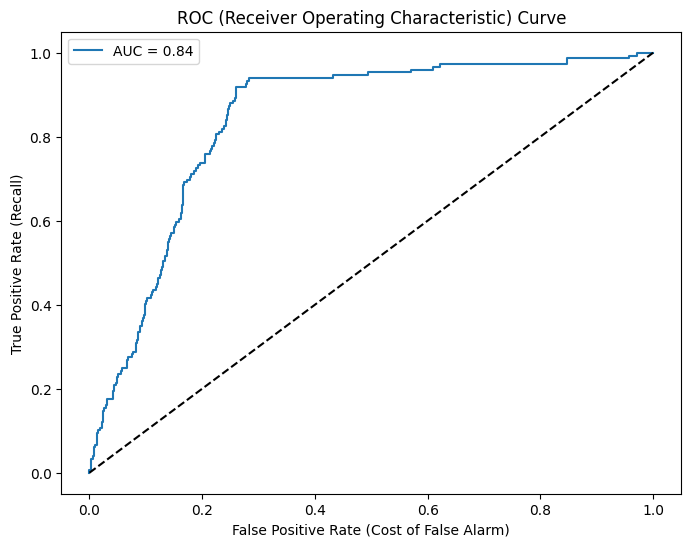

In [27]:
# Plot the ROC Curve
y_probs_XG2 = grid_search_XG2_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_XG2)
auc_XG2 = round(roc_auc_score(y_test, y_probs_XG2), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_XG2):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [28]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_XG2 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_XG2 :.4f}')

The optimal threshold is 0.5179


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [29]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_XG2)
avg_precision = average_precision_score(y_test, y_probs_XG2)

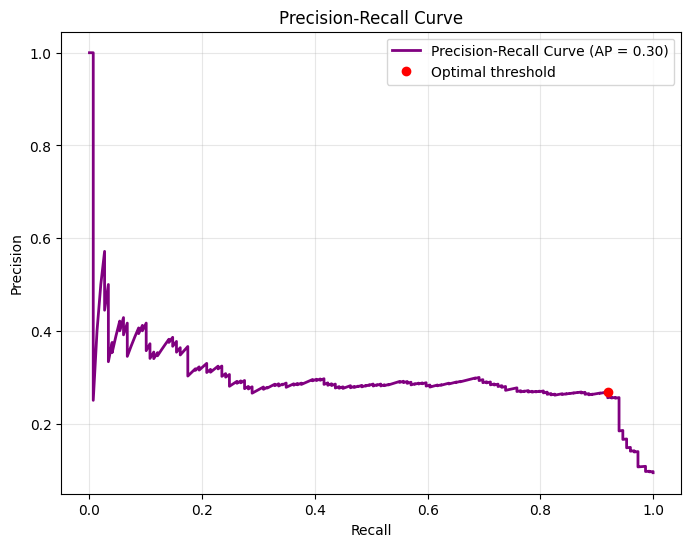

In [30]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_XG2))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [31]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_XG2 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.09 | Recall=1.00
Threshold=0.10 | Precision=0.09 | Recall=1.00
Threshold=0.15 | Precision=0.09 | Recall=1.00
Threshold=0.20 | Precision=0.09 | Recall=1.00
Threshold=0.25 | Precision=0.18 | Recall=0.95
Threshold=0.30 | Precision=0.25 | Recall=0.94
Threshold=0.35 | Precision=0.26 | Recall=0.94
Threshold=0.40 | Precision=0.25 | Recall=0.93
Threshold=0.45 | Precision=0.26 | Recall=0.93
Threshold=0.50 | Precision=0.26 | Recall=0.92
Threshold=0.55 | Precision=0.27 | Recall=0.87
Threshold=0.60 | Precision=0.28 | Recall=0.74
Threshold=0.65 | Precision=0.28 | Recall=0.52
Threshold=0.70 | Precision=0.28 | Recall=0.28
Threshold=0.75 | Precision=0.35 | Recall=0.17


In [32]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_XG2 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.35000000000000003


In [33]:
# Define Model XG2 threshold
threshold_XG2 = best_threshold

In [34]:
# Use the threshold that maximizes profit
y_pred_XG2 = (y_probs_XG2 >= threshold_XG2).astype(int)

In [35]:
# Generate classification report XG2

print(classification_report(y_test, y_pred_XG2))

              precision    recall  f1-score   support

           0       0.99      0.72      0.83      1439
           1       0.26      0.94      0.40       149

    accuracy                           0.74      1588
   macro avg       0.62      0.83      0.62      1588
weighted avg       0.92      0.74      0.79      1588



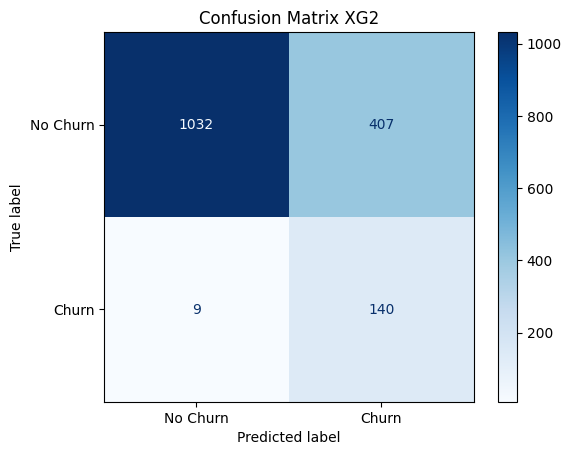

In [36]:
# Display confusion matrix XG2
conf_matrix_XG2 = confusion_matrix(y_test, y_pred_XG2)
disp_XG2 = ConfusionMatrixDisplay(conf_matrix_XG2, display_labels=['No Churn','Churn'])
disp_XG2.plot(cmap='Blues')
plt.title('Confusion Matrix XG2')
plt.show()

In [37]:
# Values for false positive (fp_XG2), false negative (fn_XG2), true positive (tp_XG2) and true negative (tn_XG2)
fp_XG2 = conf_matrix_XG2[0][1]
fn_XG2 = conf_matrix_XG2[1][0]
tp_XG2 = conf_matrix_XG2[1][1]
tn_XG2 = conf_matrix_XG2[0][0]

print(f' fp_XG2: {fp_XG2} \n fn_XG2: {fn_XG2} \n tp_XG2: {tp_XG2} \n tn_XG2: {tn_XG2}')

 fp_XG2: 407 
 fn_XG2: 9 
 tp_XG2: 140 
 tn_XG2: 1032


In [38]:
# Calculations for accuracy, precision, recall
accuracy_XG2 = (tp_XG2 + tn_XG2)/len(y_test)
precision_XG2 = tp_XG2/(tp_XG2 + fp_XG2)
recall_XG2 = tp_XG2/(tp_XG2 + fn_XG2)

print(f'Accuracy: {accuracy_XG2:.2f}')
print(f'Precision: {precision_XG2:.2f}')
print(f'Recall: {recall_XG2:.2f}')
print(f'-'*28)

Accuracy: 0.74
Precision: 0.26
Recall: 0.94
----------------------------


In [39]:
# Calculate F2 score
beta = 2
F2_score_XG2 = (1 + beta**2) * (precision_XG2 * recall_XG2) / (beta**2 * precision_XG2 + recall_XG2)

print(f'The F2 score is {F2_score_XG2:.4f}')

The F2 score is 0.6124


In [40]:
# Profit/loss analysis
Profit_Loss_XG2 = tp_XG2*(L - C) - fp_XG2*C - fn_XG2*L

print(f'The profit or loss is ${Profit_Loss_XG2}')

The profit or loss is $43620


**Feature Importance Model XG2**     
The model finds the following features to be highly important: **csat_score**, **tenure_months**, **payment_failures**, **monthly_logins**, and **tenure_fee_interaction**.


In [41]:
# Get feature names
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split('__')[1] for name in feature_names]   # Clean the feature names

print(feature_names, '\n')
print(f'There are {len(feature_names)} feature names.')

['contract_type', 'survey_response', 'gender_Male', 'country_Australia', 'country_Bangladesh', 'country_Canada', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'city_Berlin', 'city_Delhi', 'city_Dhaka', 'city_London', 'city_New York', 'city_Sydney', 'city_Toronto', 'customer_segment_Enterprise', 'customer_segment_Individual', 'customer_segment_SME', 'signup_channel_Mobile', 'signup_channel_Referral', 'signup_channel_Web', 'payment_method_Bank Transfer', 'payment_method_Card', 'payment_method_PayPal', 'discount_applied_Yes', 'price_increase_last_3m_Yes', 'complaint_type_Billing', 'complaint_type_Service', 'complaint_type_Technical', 'age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'tenure_fee_inter

In [42]:
# Get feature importance
booster = grid_search_XG2_opt.named_steps['xgb']
importances = booster.feature_importances_

print(importances, '\n')
print(f'There are {len(importances)} importances.')

[0.01614999 0.01855003 0.01669922 0.00986276 0.0150487  0.01075875
 0.00973506 0.00803349 0.0070296  0.0170821  0.01274061 0.00851374
 0.00916448 0.00929994 0.         0.0119937  0.00831774 0.01182364
 0.00745411 0.         0.01395579 0.0139504  0.01019546 0.01375713
 0.00927964 0.00705307 0.00571888 0.01667427 0.00357756 0.00763592
 0.01460442 0.01289327 0.1343189  0.06319661 0.01053515 0.01023674
 0.0127579  0.01197833 0.01195711 0.01638147 0.10492713 0.00919291
 0.01124091 0.1711662  0.00993471 0.01489448 0.01042382 0.01009965
 0.01217    0.03703453] 

There are 50 importances.


In [43]:
# Interpret the results
XG2_feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(XG2_feature_importance_df.head(30))

                         feature  importance
43                    csat_score    0.171166
32                 tenure_months    0.134319
40              payment_failures    0.104927
33                monthly_logins    0.063197
49        tenure_fee_interaction    0.037035
1                survey_response    0.018550
9                    country_USA    0.017082
2                    gender_Male    0.016699
27    price_increase_last_3m_Yes    0.016674
39                   monthly_fee    0.016381
0                  contract_type    0.016150
4             country_Bangladesh    0.015049
45               email_open_rate    0.014894
30      complaint_type_Technical    0.014604
20         signup_channel_Mobile    0.013956
21       signup_channel_Referral    0.013950
23  payment_method_Bank Transfer    0.013757
31                           age    0.012893
36                 features_used    0.012758
10                   city_Berlin    0.012741
48                referral_count    0.012170
15        

In [44]:
# Reset index
XG2_feature_importance_df = XG2_feature_importance_df.reset_index(drop=True)
XG2_feature_importance_df.index = XG2_feature_importance_df.index + 1
XG2_feature_importance_df.index.name = "Rank"

XG2_feature_importance_df.head(10)

,feature,importance
Rank,,
1,csat_score,0.171166
2,tenure_months,0.134319
3,payment_failures,0.104927
4,monthly_logins,0.063197
5,tenure_fee_interaction,0.037035
6,survey_response,0.018550
7,country_USA,0.017082
8,gender_Male,0.016699
9,price_increase_last_3m_Yes,0.016674


In [45]:
# Select the features
XG2_feature_importance_df = XG2_feature_importance_df.iloc[:20]

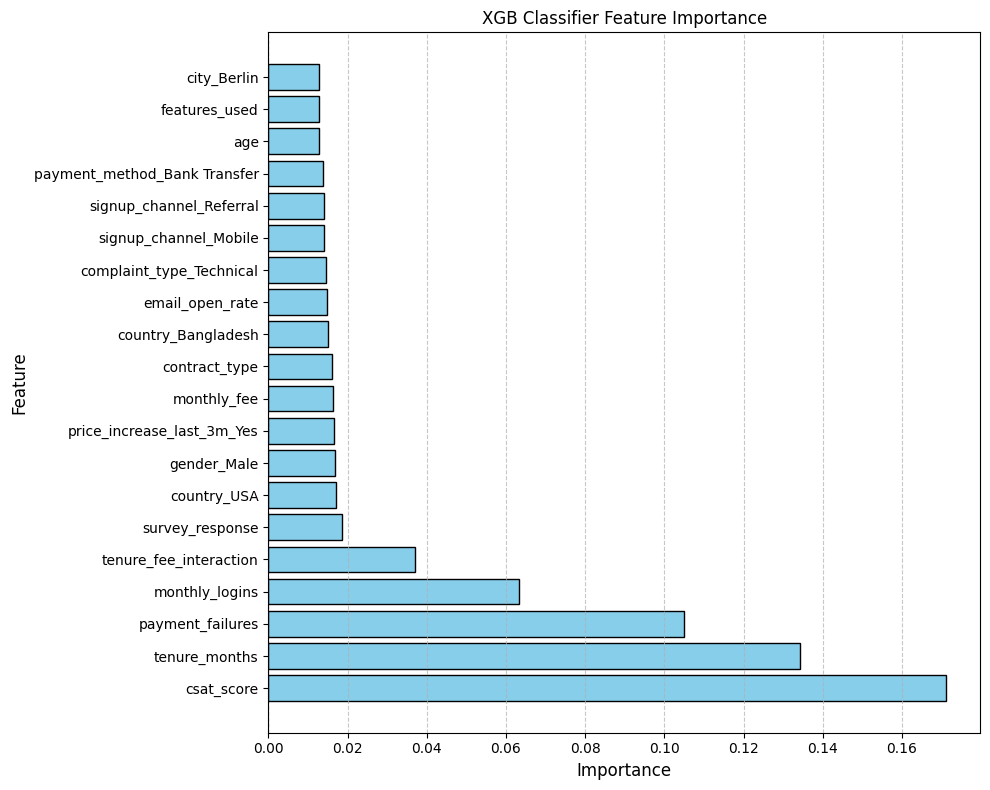

In [46]:
# Plot the features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in XG2_feature_importance_df['importance']]
plt.barh(XG2_feature_importance_df['feature'], XG2_feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('XGB Classifier Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Feature Selection**    
**Model XG3** uses SelectKBest to select the top features.

In [47]:
# Obtain the best number of features based on AUC
auc=[]
features = np.arange(17, 26, 3)
for i in features:
  # Set up selector
  selector = SelectKBest(
      score_func=mutual_info_classif,
      k=i
  )
  # Build pipeline for the improved model
  pipe = Pipeline([
      ('preprocessor', preprocessor),
      ('select', selector),
      ('xgb', XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42))
  ])
  pipe.fit(X_train, y_train)
  # Define parameter grid
  param_grid = {
      'xgb__n_estimators': [200, 300, 500],
      'xgb__max_depth': [4, 6, 8],
      'xgb__learning_rate': [0.01, 0.05, 0.1],
      'xgb__subsample': [0.7, 0.8, 1.0],
      'xgb__colsample_bytree': [0.7, 0.8, 1.0],
      'xgb__gamma': [0, 0.1, 0.3],
      'xgb__min_child_weight': [1, 3, 5]
  }
  # Run HalvingRandomSearchCV
  grid_search = HalvingRandomSearchCV(pipe, param_grid, cv=3, scoring='f1', n_jobs=-1)
  grid_search.fit(X_train, y_train)
  # Access the optimized pipeline model
  grid_search_opt = grid_search.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba = grid_search_opt.predict_proba(X_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_proba)
  auc.append(roc_auc)
  print(f'Number of Features = {i} | AUC = {roc_auc:.4f}')

Number of Features = 17 | AUC = 0.8380
Number of Features = 20 | AUC = 0.8383
Number of Features = 23 | AUC = 0.8217


In [48]:
# Determine best number of features
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 20.


In [49]:
# Set up selector on best number of features
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=best_features
)

In [50]:
# Build pipeline for the improved model
pipe_XG3 = Pipeline([
    ('preprocessor', preprocessor),
    ('select', selector),
    ('xgb', XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42))
])
pipe_XG3.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [51]:
# Define parameter grid
param_grid_XG3 = {
    'xgb__n_estimators': [200, 300, 500],
    'xgb__max_depth': [4, 6, 8],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0],
    'xgb__gamma': [0, 0.1, 0.3],
    'xgb__min_child_weight': [1, 3, 5]
}

In [52]:
# Run HalvingRandomSearchCV
grid_search_XG3 = HalvingRandomSearchCV(pipe_XG3, param_grid_XG3, cv=3, scoring='f1', n_jobs=-1)
grid_search_XG3.fit(X_train, y_train)

print(f'Best parameters: {grid_search_XG3.best_params_}')
print(f'Best score: {grid_search_XG3.best_score_:.4f}')

Best parameters: {'xgb__subsample': 1.0, 'xgb__n_estimators': 300, 'xgb__min_child_weight': 1, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.7}
Best score: 0.3615


In [53]:
# Access the optimized pipeline model
grid_search_XG3_opt = grid_search_XG3.best_estimator_

In [54]:
# Accuracy on train and test data
grid_search_XG3_opt_acc_train = grid_search_XG3_opt.score(X_train, y_train)
grid_search_XG3_opt_acc_test = grid_search_XG3_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_search_XG3_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_search_XG3_opt_acc_test*100:.2f}%')

The train accuracy of the model is 76.69%
The test accuracy of the model is 75.88%


In [55]:
# Generate classification report XG3
y_pred_XG3 = grid_search_XG3_opt.predict(X_test)

print(classification_report(y_test, y_pred_XG3))

              precision    recall  f1-score   support

           0       0.98      0.75      0.85      1439
           1       0.26      0.86      0.40       149

    accuracy                           0.76      1588
   macro avg       0.62      0.80      0.62      1588
weighted avg       0.91      0.76      0.81      1588



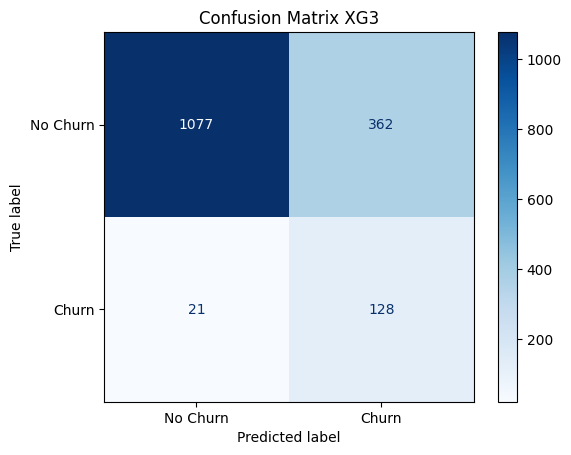

In [56]:
# Display confusion matrix XG3
conf_matrix_XG3 = confusion_matrix(y_test, y_pred_XG3)
disp_XG3 = ConfusionMatrixDisplay(conf_matrix_XG3, display_labels=['No Churn','Churn'])
disp_XG3.plot(cmap='Blues')
plt.title('Confusion Matrix XG3')
plt.show()

In [57]:
# Values for false positive (fp_XG3), false negative (fn_XG3), true positive (tp_XG3) and true negative (tn_XG3)
fp_XG3 = conf_matrix_XG3[0][1]
fn_XG3 = conf_matrix_XG3[1][0]
tp_XG3 = conf_matrix_XG3[1][1]
tn_XG3 = conf_matrix_XG3[0][0]

print(f' fp_XG3: {fp_XG3} \n fn_XG3: {fn_XG3} \n tp_XG3: {tp_XG3} \n tn_XG3: {tn_XG3}')

 fp_XG3: 362 
 fn_XG3: 21 
 tp_XG3: 128 
 tn_XG3: 1077


In [58]:
# Calculations for accuracy, precision, recall
accuracy_XG3 = (tp_XG3 + tn_XG3)/len(y_test)
precision_XG3 = tp_XG3/(tp_XG3 + fp_XG3)
recall_XG3 = tp_XG3/(tp_XG3 + fn_XG3)

print(f'Accuracy: {accuracy_XG3:.2f}')
print(f'Precision: {precision_XG3:.2f}')
print(f'Recall: {recall_XG3:.2f}')
print(f'-'*28)

Accuracy: 0.76
Precision: 0.26
Recall: 0.86
----------------------------


In [59]:
# Calculate F2 score
beta = 2
F2_score_XG3 = (1 + beta**2) * (precision_XG3 * recall_XG3) / (beta**2 * precision_XG3 + recall_XG3)

print(f'The F2 score is {F2_score_XG3:.4f}')

The F2 score is 0.5893


In [60]:
# Profit/loss analysis
Profit_Loss_XG3 = tp_XG3*(L - C) - fp_XG3*C - fn_XG3*L

print(f'The profit or loss is ${Profit_Loss_XG3}')

The profit or loss is $33900


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

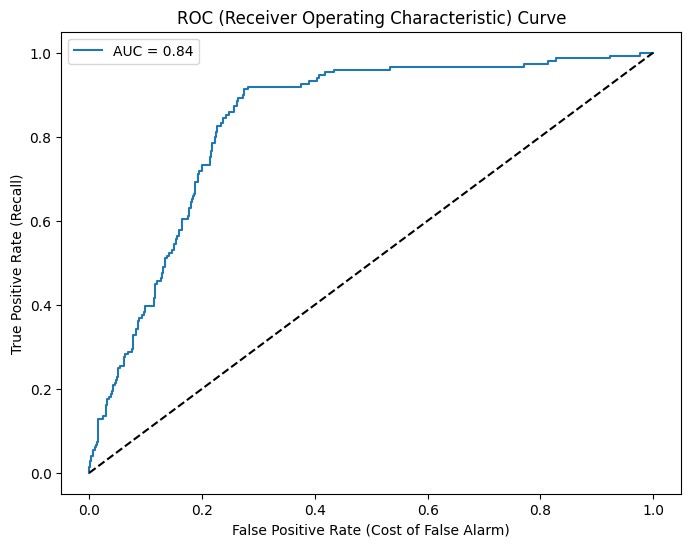

In [61]:
# Plot the ROC Curve
y_probs_XG3 = grid_search_XG3_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_XG3)
auc_XG3 = round(roc_auc_score(y_test, y_probs_XG3), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_XG3):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [62]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_XG3 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_XG3 :.4f}')

The optimal threshold is 0.3260


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [63]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_XG3)
avg_precision = average_precision_score(y_test, y_probs_XG3)

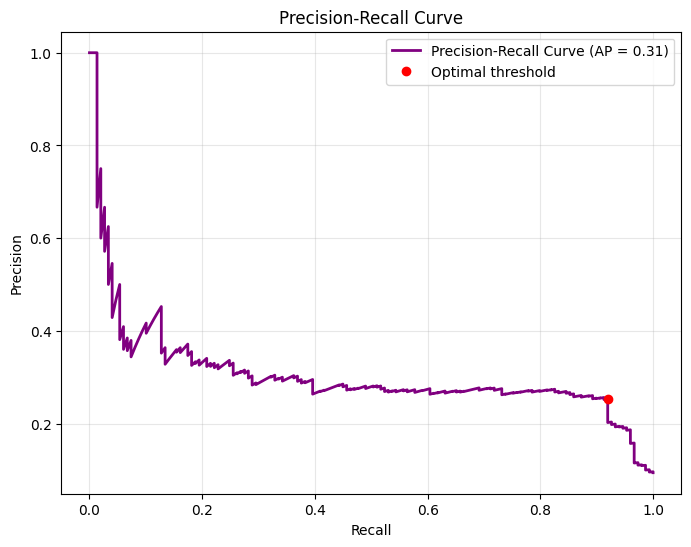

In [64]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_XG3))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [65]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_XG3 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.09 | Recall=1.00
Threshold=0.10 | Precision=0.09 | Recall=1.00
Threshold=0.15 | Precision=0.09 | Recall=1.00
Threshold=0.20 | Precision=0.12 | Recall=0.97
Threshold=0.25 | Precision=0.21 | Recall=0.92
Threshold=0.30 | Precision=0.25 | Recall=0.92
Threshold=0.35 | Precision=0.25 | Recall=0.91
Threshold=0.40 | Precision=0.26 | Recall=0.91
Threshold=0.45 | Precision=0.26 | Recall=0.89
Threshold=0.50 | Precision=0.26 | Recall=0.86
Threshold=0.55 | Precision=0.27 | Recall=0.85
Threshold=0.60 | Precision=0.27 | Recall=0.79
Threshold=0.65 | Precision=0.26 | Recall=0.60
Threshold=0.70 | Precision=0.29 | Recall=0.38
Threshold=0.75 | Precision=0.32 | Recall=0.26


In [66]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_XG3 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.3


In [67]:
# Define Model XG3 threshold
threshold_XG3 = best_threshold

In [68]:
# Use the threshold that maximizes profit
y_pred_XG3 = (y_probs_XG3 >= threshold_XG3).astype(int)

In [69]:
# Generate classification report XG30

print(classification_report(y_test, y_pred_XG3))

              precision    recall  f1-score   support

           0       0.99      0.72      0.83      1439
           1       0.25      0.92      0.39       149

    accuracy                           0.73      1588
   macro avg       0.62      0.82      0.61      1588
weighted avg       0.92      0.73      0.79      1588



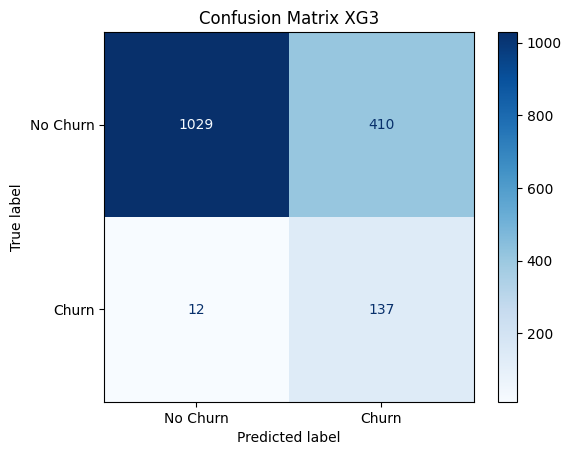

In [70]:
# Display confusion matrix XG3
conf_matrix_XG3 = confusion_matrix(y_test, y_pred_XG3)
disp_XG3 = ConfusionMatrixDisplay(conf_matrix_XG3, display_labels=['No Churn','Churn'])
disp_XG3.plot(cmap='Blues')
plt.title('Confusion Matrix XG3')
plt.show()

In [71]:
# Values for false positive (fp_XG3), false negative (fn_XG3), true positive (tp_XG3) and true negative (tn_XG3)
fp_XG3 = conf_matrix_XG3[0][1]
fn_XG3 = conf_matrix_XG3[1][0]
tp_XG3 = conf_matrix_XG3[1][1]
tn_XG3 = conf_matrix_XG3[0][0]

print(f' fp_XG3: {fp_XG3} \n fn_XG3: {fn_XG3} \n tp_XG3: {tp_XG3} \n tn_XG3: {tn_XG3}')

 fp_XG3: 410 
 fn_XG3: 12 
 tp_XG3: 137 
 tn_XG3: 1029


In [73]:
# Calculations for accuracy, precision, recall
accuracy_XG3 = (tp_XG3 + tn_XG3)/len(y_test)
precision_XG3 = tp_XG3/(tp_XG3 + fp_XG3)
recall_XG3 = tp_XG3/(tp_XG3 + fn_XG3)

print(f'Accuracy: {accuracy_XG3:.2f}')
print(f'Precision: {precision_XG3:.2f}')
print(f'Recall: {recall_XG3:.2f}')
print(f'-'*28)

Accuracy: 0.73
Precision: 0.25
Recall: 0.92
----------------------------


In [74]:
# Calculate F2 score
beta = 2
F2_score_XG3 = (1 + beta**2) * (precision_XG3 * recall_XG3) / (beta**2 * precision_XG3 + recall_XG3)

print(f'The F2 score is {F2_score_XG3:.4f}')

The F2 score is 0.5993


In [75]:
# Profit/loss analysis
Profit_Loss_XG3 = tp_XG3*(L - C) - fp_XG3*C - fn_XG3*L

print(f'The profit or loss is ${Profit_Loss_XG3}')

The profit or loss is $40620


**Feature Importance Model XG3**     
The model finds the following features to be highly important: **csat_score**, **tenure_months**, **payment_failures**, **monthly_logins**, and **tenure_fee_interaction**.

In [76]:
# Get feature names after preprocessing
feature_names = grid_search_XG3_opt.named_steps["preprocessor"].get_feature_names_out()

In [77]:
# Access the selector
selector = grid_search_XG3_opt.named_steps["select"]

In [78]:
# Get scores and selected features
scores = selector.scores_
mask = selector.get_support()
selected_features = feature_names[mask]
selected_features = [i.split('__')[-1] for i in selected_features]  # Clean feature names
selected_scores = scores[mask]

print(f'There are {len(selected_features)} selected features.')

There are 20 selected features.


In [79]:
# Match features to scores
XG3_feature_importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': selected_scores
}).sort_values(by='importance', ascending=False)

# Reset index
XG3_feature_importance_df = XG3_feature_importance_df.reset_index(drop=True)
XG3_feature_importance_df.index = XG3_feature_importance_df.index + 1
XG3_feature_importance_df.index.name = "Rank"

XG3_feature_importance_df.head(10)

,feature,importance
Rank,,
1,tenure_months,0.024423
2,csat_score,0.019361
3,tenure_fee_interaction,0.015752
4,monthly_logins,0.014216
5,payment_failures,0.012851
6,payment_method_Card,0.009048
7,country_Bangladesh,0.005853
8,survey_response,0.005625
9,escalations,0.005465


In [80]:
# Select the first twenty features
XG3_feature_importance_df = XG3_feature_importance_df.iloc[:20]

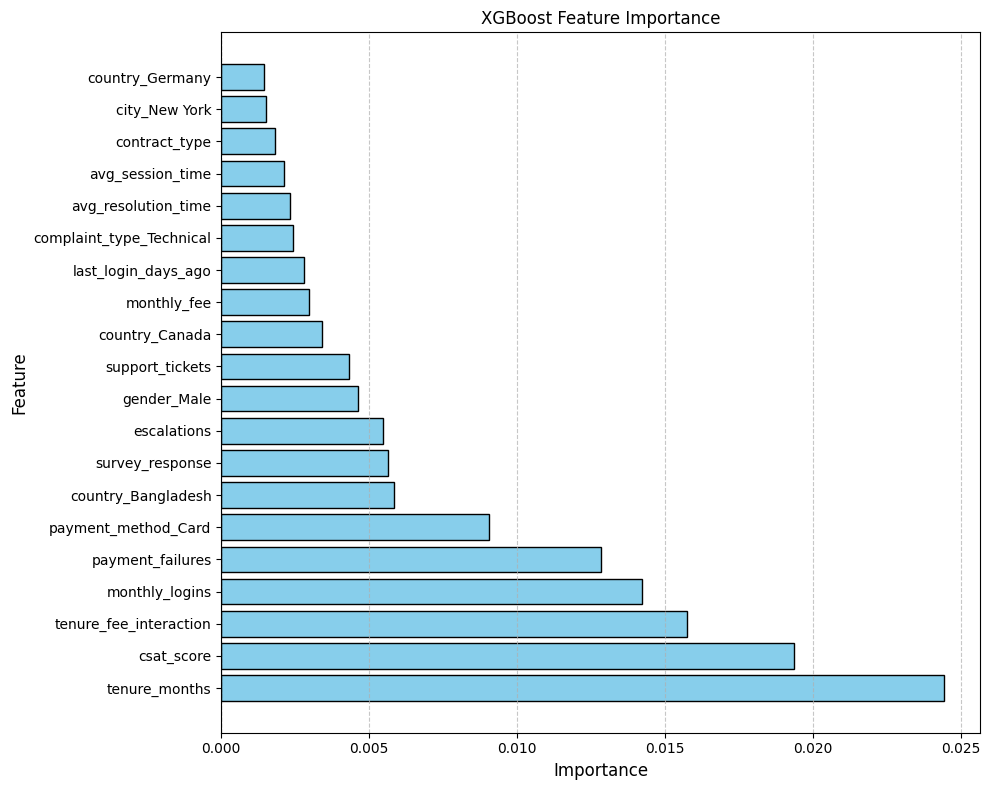

In [81]:
# Plot the feature and importance
plt.figure(figsize=(10, 8))
colors = ['skyblue']
plt.barh(XG3_feature_importance_df['feature'], XG3_feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Feature Selection**    
**Model XG4** uses Random Forest to select the top features.

In [137]:
# Obtain the best number of features based on AUC
auc=[]
features = np.arange(34, 40, 2)
for i in features:
  # Set up selector
  selector = SelectFromModel(RandomForestClassifier(random_state=42), max_features=i,
          threshold=-float("inf"))
  # Build pipeline for the improved model
  pipe = Pipeline([
      ('preprocessor', preprocessor),
      ('select', selector),
      ('xgb', XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42))
  ])
  pipe.fit(X_train, y_train)
  # Define parameter grid
  param_grid_XG4 = {
      'xgb__n_estimators': [200, 300, 400],
      'xgb__max_depth': [2, 3, 4],
      'xgb__learning_rate': [0.01, 0.03, 0.05],
      'xgb__subsample': [0.6, 0.7, 0.8],
      'xgb__colsample_bytree': [0.6, 0.7, 0.8],
      'xgb__gamma': [0.1, 0.3, 0.5, 1.0],
      'xgb__min_child_weight': [3, 5, 7],
      'xgb__reg_alpha': [0, 0.1, 1],   # L1 regularization
      'xgb__reg_lambda': [1, 5, 10]    # L2 regularization
  }
  # Run HalvingRandomSearchCV
  grid_search = HalvingRandomSearchCV(pipe, param_grid, cv=3, scoring='f1', n_jobs=-1)
  grid_search.fit(X_train, y_train)
  # Access the optimized pipeline model
  grid_search_opt = grid_search.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba = grid_search_opt.predict_proba(X_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_proba)
  auc.append(roc_auc)
  print(f'Number of Features = {i} | AUC = {roc_auc:.4f}')

Number of Features = 34 | AUC = 0.8371
Number of Features = 36 | AUC = 0.8409
Number of Features = 38 | AUC = 0.8386


In [138]:
# Determine best number of features
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 36.


In [139]:
# Set up selector on best number of features
selector = SelectFromModel(RandomForestClassifier(random_state=42), max_features=best_features,
          threshold=-float("inf"))

In [140]:
# Build pipeline for the improved model
pipe_XG4 = Pipeline([
    ('preprocessor', preprocessor),
    ('select', selector),
    ('xgb', XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42))
])
pipe_XG4.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']]),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [141]:
# Define parameter grid
param_grid_XG4 = {
    'xgb__n_estimators': [200, 300, 400],
    'xgb__max_depth': [2, 3, 4],
    'xgb__learning_rate': [0.01, 0.03, 0.05],
    'xgb__subsample': [0.6, 0.7, 0.8],
    'xgb__colsample_bytree': [0.6, 0.7, 0.8],
    'xgb__gamma': [0.1, 0.3, 0.5, 1.0],
    'xgb__min_child_weight': [3, 5, 7],
    'xgb__reg_alpha': [0, 0.1, 1],   # L1 regularization
    'xgb__reg_lambda': [1, 5, 10]    # L2 regularization
}

In [142]:
# Run HalvingRandomSearchCV
grid_search_XG4 = HalvingRandomSearchCV(pipe_XG4, param_grid_XG4, cv=3, scoring='f1', n_jobs=-1)
grid_search_XG4.fit(X_train, y_train)

print(f'Best parameters: {grid_search_XG4.best_params_}')
print(f'Best score: {grid_search_XG4.best_score_:.4f}')

Best parameters: {'xgb__subsample': 0.8, 'xgb__reg_lambda': 5, 'xgb__reg_alpha': 1, 'xgb__n_estimators': 200, 'xgb__min_child_weight': 3, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.03, 'xgb__gamma': 0.3, 'xgb__colsample_bytree': 0.8}
Best score: 0.3351


In [143]:
# Access the optimized pipeline model
grid_search_XG4_opt = grid_search_XG4.best_estimator_

In [144]:
# Accuracy on train and test data
grid_search_XG4_opt_acc_train = grid_search_XG4_opt.score(X_train, y_train)
grid_search_XG4_opt_acc_test = grid_search_XG4_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_search_XG4_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_search_XG4_opt_acc_test*100:.2f}%')

The train accuracy of the model is 79.13%
The test accuracy of the model is 76.64%


In [145]:
# Generate classification report XG4
y_pred_XG4 = grid_search_XG4_opt.predict(X_test)

print(classification_report(y_test, y_pred_XG4))

              precision    recall  f1-score   support

           0       0.98      0.76      0.86      1439
           1       0.26      0.83      0.40       149

    accuracy                           0.77      1588
   macro avg       0.62      0.79      0.63      1588
weighted avg       0.91      0.77      0.81      1588



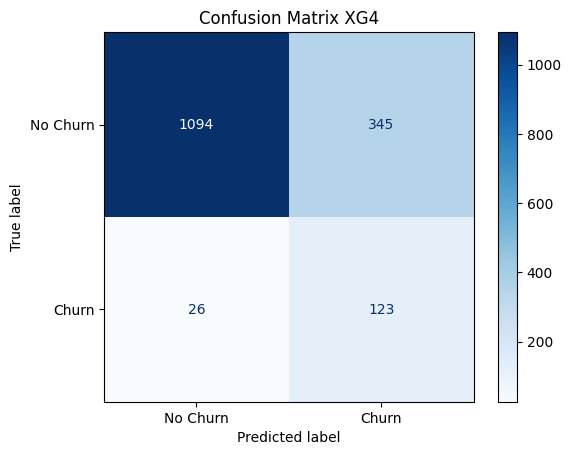

In [146]:
# Display confusion matrix XG3
conf_matrix_XG4 = confusion_matrix(y_test, y_pred_XG4)
disp_XG4 = ConfusionMatrixDisplay(conf_matrix_XG4, display_labels=['No Churn','Churn'])
disp_XG4.plot(cmap='Blues')
plt.title('Confusion Matrix XG4')
plt.show()

In [147]:
# Values for false positive (fp_XG4), false negative (fn_XG4), true positive (tp_XG4) and true negative (tn_XG4)
fp_XG4 = conf_matrix_XG4[0][1]
fn_XG4 = conf_matrix_XG4[1][0]
tp_XG4 = conf_matrix_XG4[1][1]
tn_XG4 = conf_matrix_XG4[0][0]

print(f' fp_XG4: {fp_XG4} \n fn_XG4: {fn_XG4} \n tp_XG4: {tp_XG4} \n tn_XG4: {tn_XG4}')

 fp_XG4: 345 
 fn_XG4: 26 
 tp_XG4: 123 
 tn_XG4: 1094


In [148]:
# Calculations for accuracy, precision, recall
accuracy_XG4 = (tp_XG4 + tn_XG4)/len(y_test)
precision_XG4 = tp_XG4/(tp_XG4 + fp_XG4)
recall_XG4 = tp_XG4/(tp_XG4 + fn_XG4)

print(f'Accuracy: {accuracy_XG4:.2f}')
print(f'Precision: {precision_XG4:.2f}')
print(f'Recall: {recall_XG4:.2f}')
print(f'-'*28)

Accuracy: 0.77
Precision: 0.26
Recall: 0.83
----------------------------


In [149]:
# Calculate F2 score
beta = 2
F2_score_XG4 = (1 + beta**2) * (precision_XG4 * recall_XG4) / (beta**2 * precision_XG4 + recall_XG4)

print(f'The F2 score is {F2_score_XG4:.4f}')

The F2 score is 0.5780


In [150]:
# Profit/loss analysis
Profit_Loss_XG4 = tp_XG4*(L - C) - fp_XG4*C - fn_XG4*L

print(f'The profit or loss is ${Profit_Loss_XG4}')

The profit or loss is $29780


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

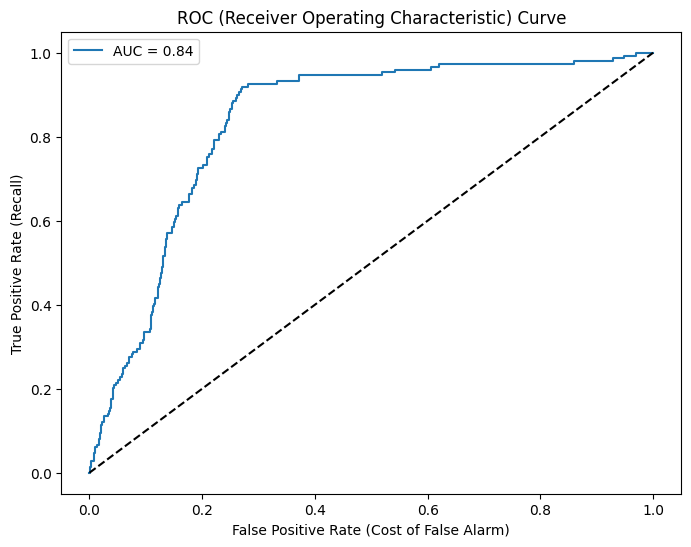

In [151]:
# Plot the ROC Curve
y_probs_XG4 = grid_search_XG4_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_XG4)
auc_XG4 = round(roc_auc_score(y_test, y_probs_XG4), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_XG4):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [152]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_XG4 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_XG4 :.4f}')

The optimal threshold is 0.3861


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [153]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_XG4)
avg_precision = average_precision_score(y_test, y_probs_XG4)

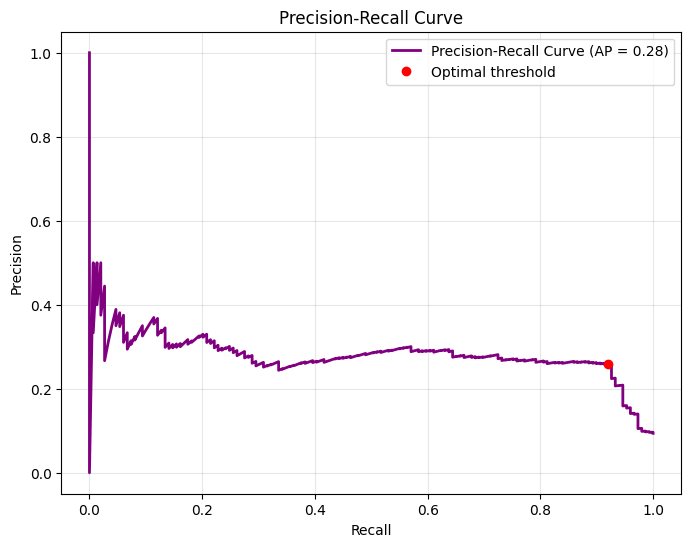

In [154]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_XG4))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [155]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_XG4 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.09 | Recall=1.00
Threshold=0.10 | Precision=0.10 | Recall=0.99
Threshold=0.15 | Precision=0.12 | Recall=0.97
Threshold=0.20 | Precision=0.18 | Recall=0.95
Threshold=0.25 | Precision=0.22 | Recall=0.93
Threshold=0.30 | Precision=0.25 | Recall=0.93
Threshold=0.35 | Precision=0.26 | Recall=0.92
Threshold=0.40 | Precision=0.26 | Recall=0.91
Threshold=0.45 | Precision=0.26 | Recall=0.89
Threshold=0.50 | Precision=0.26 | Recall=0.83
Threshold=0.55 | Precision=0.27 | Recall=0.77
Threshold=0.60 | Precision=0.28 | Recall=0.67
Threshold=0.65 | Precision=0.29 | Recall=0.57
Threshold=0.70 | Precision=0.25 | Recall=0.34
Threshold=0.75 | Precision=0.30 | Recall=0.23


In [156]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_XG4 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.3


In [157]:
# Define Model XG4 threshold
threshold_XG4 = best_threshold

In [158]:
# Use the threshold that maximizes profit
y_pred_XG4 = (y_probs_XG4 >= threshold_XG4).astype(int)

In [159]:
# Generate classification report XG4

print(classification_report(y_test, y_pred_XG4))

              precision    recall  f1-score   support

           0       0.99      0.71      0.82      1439
           1       0.25      0.93      0.39       149

    accuracy                           0.73      1588
   macro avg       0.62      0.82      0.61      1588
weighted avg       0.92      0.73      0.78      1588



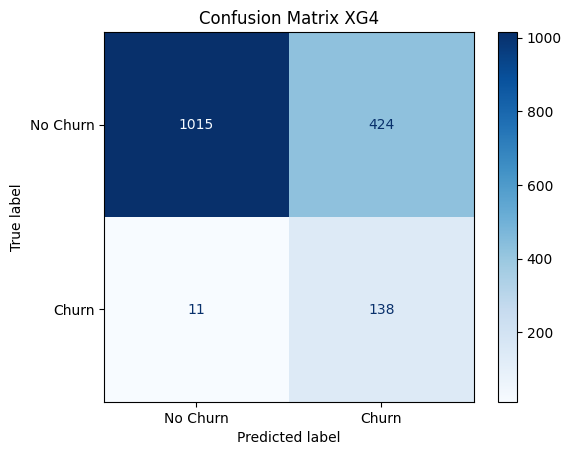

In [160]:
# Display confusion matrix XG3
conf_matrix_XG4 = confusion_matrix(y_test, y_pred_XG4)
disp_XG4 = ConfusionMatrixDisplay(conf_matrix_XG4, display_labels=['No Churn','Churn'])
disp_XG4.plot(cmap='Blues')
plt.title('Confusion Matrix XG4')
plt.show()

In [161]:
# Values for false positive (fp_XG4), false negative (fn_XG4), true positive (tp_XG4) and true negative (tn_XG4)
fp_XG4 = conf_matrix_XG4[0][1]
fn_XG4 = conf_matrix_XG4[1][0]
tp_XG4 = conf_matrix_XG4[1][1]
tn_XG4 = conf_matrix_XG4[0][0]

print(f' fp_XG4: {fp_XG4} \n fn_XG4: {fn_XG4} \n tp_XG4: {tp_XG4} \n tn_XG4: {tn_XG4}')

 fp_XG4: 424 
 fn_XG4: 11 
 tp_XG4: 138 
 tn_XG4: 1015


In [162]:
# Calculations for accuracy, precision, recall
accuracy_XG4 = (tp_XG4 + tn_XG4)/len(y_test)
precision_XG4 = tp_XG4/(tp_XG4 + fp_XG4)
recall_XG4 = tp_XG4/(tp_XG4 + fn_XG4)

print(f'Accuracy: {accuracy_XG4:.2f}')
print(f'Precision: {precision_XG4:.2f}')
print(f'Recall: {recall_XG4:.2f}')
print(f'-'*28)

Accuracy: 0.73
Precision: 0.25
Recall: 0.93
----------------------------


In [163]:
# Calculate F2 score
beta = 2
F2_score_XG4 = (1 + beta**2) * (precision_XG4 * recall_XG4) / (beta**2 * precision_XG4 + recall_XG4)

print(f'The F2 score is {F2_score_XG4:.4f}')

The F2 score is 0.5959


In [164]:
# Profit/loss analysis
Profit_Loss_XG4 = tp_XG4*(L - C) - fp_XG4*C - fn_XG4*L

print(f'The profit or loss is ${Profit_Loss_XG4}')

The profit or loss is $41020


**Feature Importance Model XG4**     
The model finds the following features to be highly important: **csat_score**, **tenure_months**, **payment_failures**, **monthly_logins**, and **tenure_fee_interaction**.

In [165]:
# Extract the selector from the pipeline
selector = grid_search_XG4_opt.named_steps["select"]

In [166]:
# Access the Random Forest model for the importances
rf_model = selector.estimator_
importances = rf_model.feature_importances_

In [167]:
# Get feature names from the preprocessor
feature_names = grid_search_XG4_opt.named_steps["preprocessor"].get_feature_names_out()

In [168]:
# Get only selected features
mask = selector.get_support()
selected_features = feature_names[mask]
selected_importances = importances[mask]
selected_features = [i.split('__')[-1] for i in selected_features]  # Clean feature names

print(f'There are {len(selected_features)} selected features.')

There are 36 selected features.


In [169]:
# Build features importance dataframe
XG4_feature_importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance": selected_importances
}).sort_values(by="importance", ascending=False)

# Reset index
XG4_feature_importance_df = XG4_feature_importance_df.reset_index(drop=True)
XG4_feature_importance_df.index = XG4_feature_importance_df.index + 1
XG4_feature_importance_df.index.name = "Rank"

XG4_feature_importance_df.head(10)

,feature,importance
Rank,,
1,tenure_months,0.075653
2,monthly_logins,0.069643
3,tenure_fee_interaction,0.066292
4,csat_score,0.055930
5,avg_session_time,0.052271
6,avg_resolution_time,0.051568
7,email_open_rate,0.047765
8,nps_score,0.047715
9,usage_growth_rate,0.046427


In [170]:
# Select the first twenty features
XG4_feature_importance_df = XG4_feature_importance_df.iloc[:20]

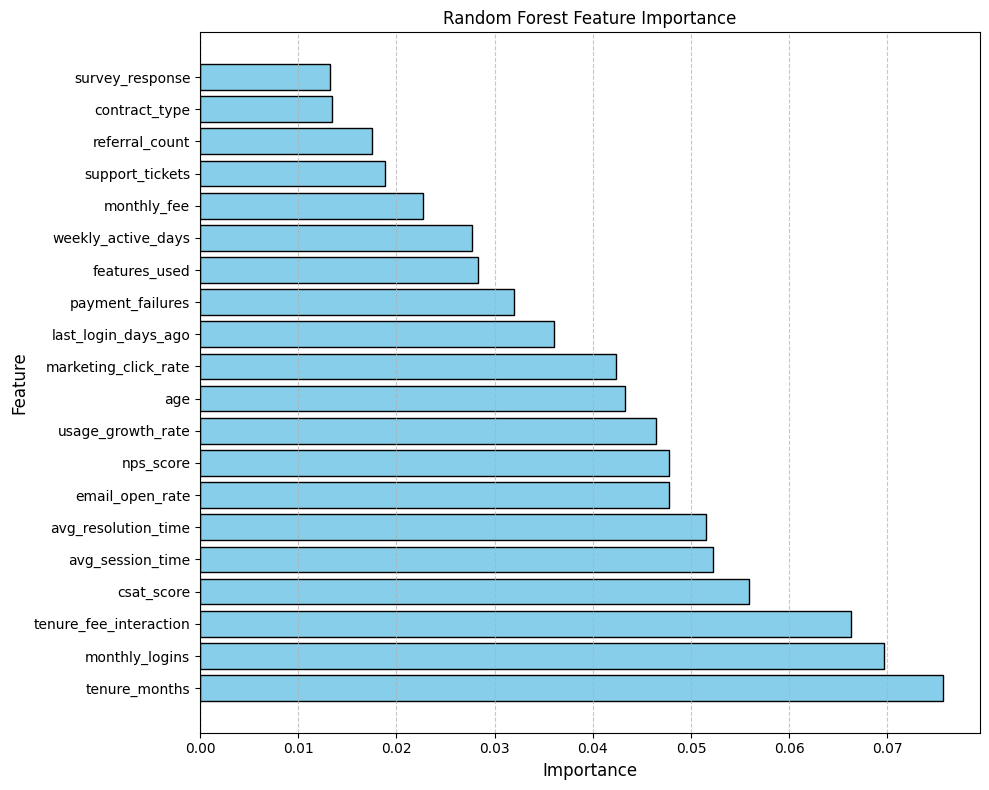

In [171]:
# Plot the important features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in XG4_feature_importance_df['importance']]
plt.barh(XG4_feature_importance_df['feature'], XG4_feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Model Summary**     
A dataframe is plotted to summarize the AUC, accuracy, precision, recall, F2 score and profit/loss for the different Random Forest models.     

The ultimate choice of the predictive model would need to consider the actual relative cost of missing a churner (false negatives - predicted not to churn but churned) and false alarms (false positives - predicted to churn but stayed) in order to determine the optimum mix of precision and recall.  

In [172]:
# Build a comparison dataframe
xgb_models_df = pd.DataFrame({
    'XGB Classifier': ['Model XG2','Model XG3', 'Model XG4'],
    'AUC': [auc_XG2, auc_XG3, auc_XG4],
    'Accuracy': [accuracy_XG2, accuracy_XG3, accuracy_XG4],
    'Precision': [precision_XG2, precision_XG3, precision_XG4],
    'Recall': [recall_XG2, recall_XG3, recall_XG4],
    'F2 Score': [F2_score_XG2, F2_score_XG3, F2_score_XG4],
    'Profit/Loss': [Profit_Loss_XG2, Profit_Loss_XG3, Profit_Loss_XG4],
})
xgb_models_df

,XGB Classifier,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
0,Model XG2,0.840,0.738035,0.255941,0.939597,0.612423,43620
1,Model XG3,0.837,0.734257,0.250457,0.919463,0.599300,40620
2,Model XG4,0.835,0.726071,0.245552,0.926174,0.595855,41020


In [173]:
# Provide an interactive Plotly plot
fig = go.Figure()

#Primary y-axis
metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F2 Score']

for metric in metrics:
  fig.add_trace(
        go.Scatter(
          x=xgb_models_df['XGB Classifier'],
          y=xgb_models_df[metric],
          mode='lines+markers',
          name=metric,
          yaxis='y1'
        )
    )

# Secondary y-axis
fig.add_trace(
        go.Bar(
          x=xgb_models_df['XGB Classifier'],
          y=xgb_models_df['Profit/Loss'],
          name='Profit/Loss',
          yaxis='y2',
          opacity=0.35
        )
)
# Layout
fig.update_layout(
        title='Model Performance and Profit/Loss',
        xaxis=dict(title='XGB Classifier'),
        yaxis=dict(
            title='Score',
            range=[0, 1]
        ),
        yaxis2=dict(
            title='Profit/Loss ($)',
            overlaying='y',
            side='right'
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        template='plotly_white',
        hovermode='x unified'
)
fig.show()

In [174]:
# Output the best XGBoost model performance metrics based on profit/loss
xgb_metrics_df = xgb_models_df.loc[[xgb_models_df["Profit/Loss"].idxmax()]]

xgb_metrics_df.to_csv("xgb_metrics.csv", index=False)

xgb_metrics_df.head()

,XGB Classifier,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
0,Model XG2,0.84,0.738035,0.255941,0.939597,0.612423,43620


In [175]:
# Output the first eight (8) features importance
model = xgb_metrics_df.iloc[0, 0]

if model == 'Model XG2':
  print(XG2_feature_importance_df.head(8), '\n')
  XG2_feature_importance_df.to_csv("xgb_features.csv", index=False)
elif model == 'Model XG3':
  print(XG3_feature_importance_df.head(8), '\n')
  XG3_feature_importance_df.to_csv("xgb_features.csv", index=False)
else:
  print(XG4_feature_importance_df.head(8), '\n')
  XG4_feature_importance_df.to_csv("xgb_features.csv", index=False)

print(f'The best model is {model}.')

                     feature  importance
Rank                                    
1                 csat_score    0.171166
2              tenure_months    0.134319
3           payment_failures    0.104927
4             monthly_logins    0.063197
5     tenure_fee_interaction    0.037035
6            survey_response    0.018550
7                country_USA    0.017082
8                gender_Male    0.016699 

The best model is Model XG2.


**Sample Predictions**

In [176]:
# Establish best model
model = xgb_metrics_df.iloc[0, 0]

if model == 'Model XG2':
  model_opt = grid_search_XG2_opt
  best_threshold = threshold_XG2
elif model == 'Model XG3':
  model_opt = grid_search_XG3_opt
  best_threshold = threshold_XG3
else:
  model_opt = grid_search_XG4_opt
  best_threshold = threshold_XG4

print(f'The best model is {model} and the best threshold is {best_threshold}.')

The best model is Model XG2 and the best threshold is 0.35000000000000003.


**Sample 1**

In [177]:
# Obtain a sample from the test data
df_test1 = X_test[264:265]

print(df_test1.head().T, '\n')
print(f'Actual churn is {list(y_test[264:265])[0]}') # verify churn

                                 1862
gender                         Female
age                                62
country                        Canada
city                           Sydney
customer_segment           Individual
tenure_months                      18
signup_channel               Referral
contract_type                 Monthly
monthly_logins                     19
weekly_active_days                  1
avg_session_time            23.353293
features_used                       5
usage_growth_rate               -0.01
last_login_days_ago                 5
monthly_fee                        50
payment_method          Bank Transfer
payment_failures                    2
discount_applied                   No
price_increase_last_3m             No
support_tickets                     2
avg_resolution_time         24.419612
complaint_type                Billing
csat_score                        3.0
escalations                         0
email_open_rate                  0.33
marketing_cl

In [178]:
# Transfer the data to a dictionary
sample1 = {
    "gender": "Female",
    "age": 62,
    "country": "Canada",
    "city": "Sydney",
    "customer_segment": "Individual",
    "tenure_months": 18,
    "signup_channel": "Referral",
    "contract_type": "Monthly",
    "monthly_logins": 19,
    "weekly_active_days": 1,
    "avg_session_time": 23.353293,
    "features_used": 5,
    "usage_growth_rate": -0.01,
    "last_login_days_ago": 5,
    "monthly_fee": 50,
    "payment_method": "Bank Transfer",
    "payment_failures": 2,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 2,
    "avg_resolution_time": 24.419612,
    "complaint_type": "Billing",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.33,
    "marketing_click_rate": 0.49,
    "nps_score": -15,
    "survey_response": "Satisfied",
    "referral_count": 1,
    "tenure_fee_interaction": 900
}

In [179]:
# Calculate churn probability of the sample and provide churn of the sample
probability1 = model_opt.predict_proba(pd.DataFrame([sample1]))[:, 1][0]

if probability1 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability1:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.61


**Sample 2**

In [180]:
# Obtain a sample from the test data
df_test2 = X_test[399:400]

print(df_test2.head().T, '\n')
print(f'The actual churn is {list(y_test[399:400])[0]}') # verify churn

                             1495
gender                       Male
age                            33
country                     India
city                     New York
customer_segment              SME
tenure_months                  40
signup_channel             Mobile
contract_type           Quarterly
monthly_logins                 10
weekly_active_days              2
avg_session_time        20.705153
features_used                   4
usage_growth_rate           -0.33
last_login_days_ago             0
monthly_fee                    50
payment_method               Card
payment_failures                0
discount_applied               No
price_increase_last_3m         No
support_tickets                 0
avg_resolution_time     31.927794
complaint_type          Technical
csat_score                    3.0
escalations                     0
email_open_rate              0.17
marketing_click_rate         0.15
nps_score                      70
survey_response           Neutral
referral_count

In [181]:
# Transfer the data to a dictionary
sample2 = {
    "gender": "Male",
    "age": 33,
    "country": "India",
    "city": "New York",
    "customer_segment": "SME",
    "tenure_months": 40,
    "signup_channel": "Mobile",
    "contract_type": "Quarterly",
    "monthly_logins": 10,
    "weekly_active_days": 2,
    "avg_session_time": 20.705153,
    "features_used": 4,
    "usage_growth_rate": -0.33,
    "last_login_days_ago": 0,
    "monthly_fee": 50,
    "payment_method": "Card",
    "payment_failures": 0,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 0,
    "avg_resolution_time": 31.927794,
    "complaint_type": "Technical",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.17,
    "marketing_click_rate": 0.15,
    "nps_score": 70,
    "survey_response": "Neutral",
    "referral_count": 2,
    "tenure_fee_interaction": 2000
}

In [182]:
# Calculate churn probability of the sample and provide churn of the sample
probability2 = model_opt.predict_proba(pd.DataFrame([sample2]))[:, 1]

if probability2 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability2[0]:.2f}')

The predicted churn is 0 

The predicted churn probability is 0.22


**Sample 3**

In [183]:
# Obtain a sample from the test data
df_test3 = X_test[999:1000]

print(df_test3.head().T, '\n')
print(f'The actual churn is {list(y_test[999:1000])[0]}') # verify churn

                              5713
gender                      Female
age                             51
country                      India
city                         Dhaka
customer_segment        Individual
tenure_months                   12
signup_channel              Mobile
contract_type            Quarterly
monthly_logins                  12
weekly_active_days               7
avg_session_time         10.737885
features_used                    7
usage_growth_rate            -0.11
last_login_days_ago              4
monthly_fee                     50
payment_method                Card
payment_failures                 0
discount_applied               Yes
price_increase_last_3m          No
support_tickets                  3
avg_resolution_time      23.828534
complaint_type             Billing
csat_score                     4.0
escalations                      0
email_open_rate               0.18
marketing_click_rate          0.48
nps_score                       40
survey_response     

In [184]:
# Place the sample data in a dictionary
sample3 = {
    "gender": "Female",
    "age": 51,
    "country": "India",
    "city": "Dhaka",
    "customer_segment": "Individual",
    "tenure_months": 12,
    "signup_channel": "Mobile",
    "contract_type": "Quarterly",
    "monthly_logins": 12,
    "weekly_active_days": 7,
    "avg_session_time": 10.737885,
    "features_used": 7,
    "usage_growth_rate": -0.11,
    "last_login_days_ago": 4,
    "monthly_fee": 50,
    "payment_method": "Card",
    "payment_failures": 0,
    "discount_applied": "Yes",
    "price_increase_last_3m": "No",
    "support_tickets": 3,
    "avg_resolution_time": 23.828534,
    "complaint_type": "Billing",
    "csat_score": 4.0,
    "escalations": 0,
    "email_open_rate": 0.18,
    "marketing_click_rate": 0.48,
    "nps_score": 40,
    "survey_response": "Satisfied",
    "referral_count": 2,
    "tenure_fee_interaction": 600
}

In [185]:
# Calculate churn probability of the sample and provide churn of the sample
probability3 = model_opt.predict_proba(pd.DataFrame([sample3]))[:, 1]

if probability3 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability3[0]:.2f}')

The predicted churn is 0 

The predicted churn probability is 0.23


**Sample 4**

In [186]:
# Obtain another sample from the test data
df_test4 = X_test[125:126]

print(df_test4.head().T, '\n')
print(f'The actual churn is {list(y_test[125:126])[0]}') # verify churn

                                 5786
gender                         Female
age                                51
country                    Bangladesh
city                           London
customer_segment           Individual
tenure_months                      58
signup_channel               Referral
contract_type               Quarterly
monthly_logins                      0
weekly_active_days                  3
avg_session_time            14.899728
features_used                       5
usage_growth_rate                0.11
last_login_days_ago                14
monthly_fee                        20
payment_method          Bank Transfer
payment_failures                    0
discount_applied                   No
price_increase_last_3m             No
support_tickets                     0
avg_resolution_time         13.387985
complaint_type              Technical
csat_score                        4.0
escalations                         0
email_open_rate                  0.22
marketing_cl

In [187]:
# Place the sample data in a dictionary
sample4 = {
    "gender": "Female",
    "age": 51,
    "country": "Bangladesh",
    "city": "London",
    "customer_segment": "Individual",
    "tenure_months": 58,
    "signup_channel": "Referral",
    "contract_type": "Quarterly",
    "monthly_logins": 0,
    "weekly_active_days": 3,
    "avg_session_time": 14.899728,
    "features_used": 5,
    "usage_growth_rate": 0.11,
    "last_login_days_ago": 14,
    "monthly_fee": 20,
    "payment_method": "Bank Transfer",
    "payment_failures": 0,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 0,
    "avg_resolution_time": 13.387985,
    "complaint_type": "Technical",
    "csat_score": 4.0,
    "escalations": 0,
    "email_open_rate": 0.22,
    "marketing_click_rate": 0.19,
    "nps_score": 50,
    "survey_response": "Satisfied",
    "referral_count": 0,
    "tenure_fee_interaction": 1160
}

In [188]:
# Calculate churn probability of the sample and provide churn of the sample
probability4 = model_opt.predict_proba(pd.DataFrame([sample4]))[:, 1]

if probability4 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability4[0]:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.64


Sample 5

In [189]:
# Obtain another sample from the test data
df_test5 = X_test[1125:1126]

print(df_test5.head().T, '\n')
print(f'The actual churn is {list(y_test[1125:1126])[0]}') # verify churn

                              6970
gender                      Female
age                             38
country                         UK
city                        Sydney
customer_segment        Individual
tenure_months                   14
signup_channel                 Web
contract_type              Monthly
monthly_logins                  10
weekly_active_days               3
avg_session_time         10.354267
features_used                    5
usage_growth_rate            -0.14
last_login_days_ago              3
monthly_fee                     50
payment_method                Card
payment_failures                 1
discount_applied                No
price_increase_last_3m          No
support_tickets                  1
avg_resolution_time       9.362325
complaint_type             Service
csat_score                     3.0
escalations                      0
email_open_rate               0.56
marketing_click_rate          0.49
nps_score                       87
survey_response     

In [190]:
# Place the sample data in a dictionary
sample5 = {
    "gender": "Female",
    "age": 38,
    "country": "UK",
    "city": "Sydney",
    "customer_segment": "Individual",
    "tenure_months": 14,
    "signup_channel": "Web",
    "contract_type": "Monthly",
    "monthly_logins": 10,
    "weekly_active_days": 3,
    "avg_session_time": 10.354267,
    "features_used": 5,
    "usage_growth_rate": -0.14,
    "last_login_days_ago": 3,
    "monthly_fee": 50,
    "total_revenue": 700,
    "payment_method": "Card",
    "payment_failures": 1,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 1,
    "avg_resolution_time": 9.362325,
    "complaint_type": "Service",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.56,
    "marketing_click_rate": 0.49,
    "nps_score": 87,
    "survey_response": "Neutral",
    "referral_count": 0,
    "tenure_fee_interaction": 700
}

In [191]:
# Calculate churn probability of the sample and provide churn of the sample
probability5 = model_opt.predict_proba(pd.DataFrame([sample5]))[:, 1]

if probability5 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability5[0]:.2f}')

The predicted churn is 0 

The predicted churn probability is 0.25
